In [1]:
#kodlama olacak, kodlama boşluk doldurma olarak olacak. Kitap defter açık
#haftaya kadar streamlit'e bak

In [2]:
import pandas as pd
df_coffee=pd.read_feather("resources/coffee_ratings_full.feather")
df_coffee

,total_cup_points,species,owner,country_of_origin,farm_name,lot_number,mill,ico_number,company,altitude,...,color,category_two_defects,expiration,certification_body,certification_address,certification_contact,unit_of_measurement,altitude_low_meters,altitude_high_meters,altitude_mean_meters
0,90.58,Arabica,metad plc,Ethiopia,metad plc,None,metad plc,2014/2015,metad agricultural developmet plc,1950-2200,...,Green,0.0,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1950.0,2200.0,2075.0
1,89.92,Arabica,metad plc,Ethiopia,metad plc,None,metad plc,2014/2015,metad agricultural developmet plc,1950-2200,...,Green,1.0,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1950.0,2200.0,2075.0
2,89.75,Arabica,grounds for health admin,Guatemala,"san marcos barrancas ""san cristobal cuch",None,None,None,None,1600 - 1800 m,...,None,0.0,"May 31st, 2011",Specialty Coffee Association,36d0d00a3724338ba7937c52a378d085f2172daa,0878a7d4b9d35ddbf0fe2ce69a2062cceb45a660,m,1600.0,1800.0,1700.0
3,89.00,Arabica,yidnekachew dabessa,Ethiopia,yidnekachew dabessa coffee plantation,None,wolensu,None,yidnekachew debessa coffee plantation,1800-2200,...,Green,2.0,"March 25th, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1800.0,2200.0,2000.0
4,88.83,Arabica,metad plc,Ethiopia,metad plc,None,metad plc,2014/2015,metad agricultural developmet plc,1950-2200,...,Green,2.0,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1950.0,2200.0,2075.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,78.75,Robusta,luis robles,Ecuador,robustasa,Lavado 1,our own lab,None,robustasa,None,...,Blue-Green,1.0,"January 18th, 2017",Specialty Coffee Association,ff7c18ad303d4b603ac3f8cff7e611ffc735e720,352d0cf7f3e9be14dad7df644ad65efc27605ae2,m,NaN,NaN,NaN
1334,78.08,Robusta,luis robles,Ecuador,robustasa,Lavado 3,own laboratory,None,robustasa,40,...,Blue-Green,0.0,"January 18th, 2017",Specialty Coffee Association,ff7c18ad303d4b603ac3f8cff7e611ffc735e720,352d0cf7f3e9be14dad7df644ad65efc27605ae2,m,40.0,40.0,40.0
1335,77.17,Robusta,james moore,United States,fazenda cazengo,None,cafe cazengo,None,global opportunity fund,795 meters,...,None,6.0,"December 23rd, 2015",Specialty Coffee Association,ff7c18ad303d4b603ac3f8cff7e611ffc735e720,352d0cf7f3e9be14dad7df644ad65efc27605ae2,m,795.0,795.0,795.0
1336,75.08,Robusta,cafe politico,India,None,None,None,14-1118-2014-0087,cafe politico,None,...,Green,1.0,"August 25th, 2015",Specialty Coffee Association,ff7c18ad303d4b603ac3f8cff7e611ffc735e720,352d0cf7f3e9be14dad7df644ad65efc27605ae2,m,NaN,NaN,NaN


In [3]:
coffee_focus=df_coffee[["variety","country_of_origin","flavor"]] #seçilen üç alandaki verilerle işlem yapılacak
coffee_focus=coffee_focus.reset_index() #indekseleri bir alan olarak göstetir
coffee_focus

#yerine koyarak örnekleme yapacağımdan dolayı indeksleri alan olarak almam lazımdı.

,index,variety,country_of_origin,flavor
0,0,None,Ethiopia,8.83
1,1,Other,Ethiopia,8.67
2,2,Bourbon,Guatemala,8.50
3,3,None,Ethiopia,8.58
4,4,Other,Ethiopia,8.50
...,...,...,...,...
1333,1333,None,Ecuador,7.58
1334,1334,None,Ecuador,7.67
1335,1335,None,United States,7.33
1336,1336,None,India,6.83


In [4]:
#resampling
coffee_resamp=coffee_focus.sample(frac=1,replace=True)
coffee_resamp
#verisetindeki veri adetince aldığımız veriyi tekrar kullanma (replace=True) açık olarak bir örnekleme yaparız

,index,variety,country_of_origin,flavor
237,237,Hawaiian Kona,United States (Hawaii),7.75
287,287,Caturra,Colombia,7.58
584,584,Bourbon,Guatemala,7.58
711,711,Catimor,China,7.58
248,248,Caturra,Colombia,7.42
...,...,...,...,...
988,988,Other,Nicaragua,7.33
368,368,Typica,Mexico,7.75
519,519,Typica,Mexico,7.83
827,827,Typica,Mexico,7.50


In [5]:
coffee_resamp["index"].value_counts()
#her bir indexin ne kadar sıklıkla geçtiğine bakıyoruz

index
277     6
474     5
1049    5
257     4
916     4
       ..
356     1
471     1
1234    1
502     1
827     1
Name: count, Length: 853, dtype: int64

In [6]:
num_unique_coffees=len(coffee_resamp.drop_duplicates(subset="index"))
num_unique_coffees
#örneklem içerisinde unique olan index sayısı kaç onu bulmak için drop_duplicates kullanılır
#bu fonskiyoon index alanında tekrar eden indexleri almaz.

853

In [7]:
'''
-------------------bootstrapping---------------------------
elimizdeki veri setini örneklem olarak düşünülür

'''
import numpy as np

mean_flavors_1000=[]

for i in range(1000):
    mean_flavors_1000.append(np.mean(coffee_focus.sample(frac=1,replace=True)["flavor"]))

(array([  6.,  22.,  94., 165., 251., 218., 149.,  66.,  21.,   8.]),
 array([7.49671151, 7.50273916, 7.50876682, 7.51479447, 7.52082212,
        7.52684978, 7.53287743, 7.53890508, 7.54493274, 7.55096039,
        7.55698804]),
 <BarContainer object of 10 artists>)

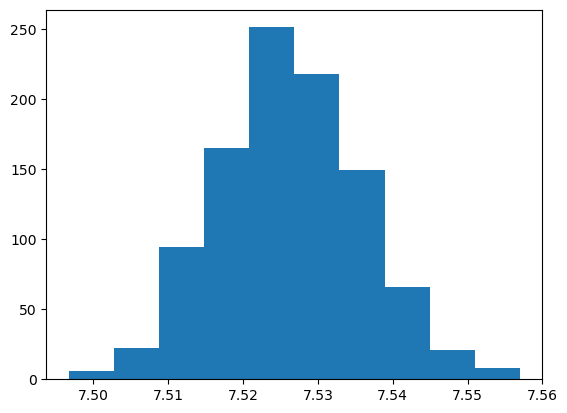

In [8]:
import matplotlib.pyplot as plt

#bootsrapping histogram
plt.hist(mean_flavors_1000)

(array([  6.,  15.,  32., 149., 291., 480., 304.,  39.,  15.,   7.]),
 array([6.08 , 6.355, 6.63 , 6.905, 7.18 , 7.455, 7.73 , 8.005, 8.28 ,
        8.555, 8.83 ]),
 <BarContainer object of 10 artists>)

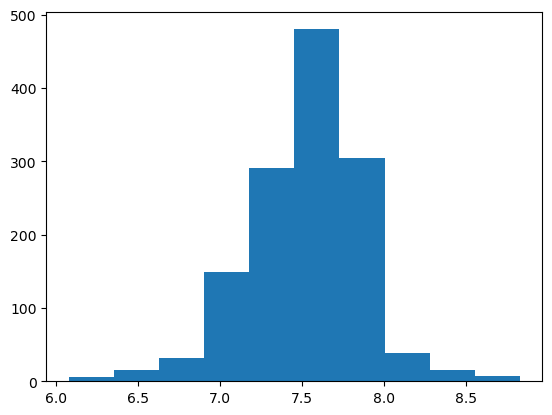

In [9]:
plt.hist(df_coffee["flavor"])

(array([  2.,   4.,  11.,  33.,  84., 169., 145.,  32.,  11.,   9.]),
 array([6.08 , 6.339, 6.598, 6.857, 7.116, 7.375, 7.634, 7.893, 8.152,
        8.411, 8.67 ]),
 <BarContainer object of 10 artists>)

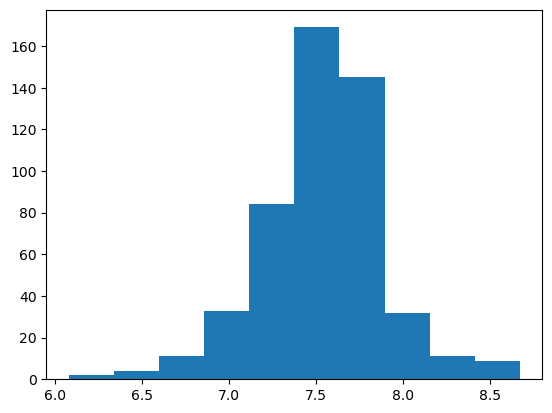

In [10]:
#comparing sampling and bootstrap disct.

coffee_sample=df_coffee[["variety","country_of_origin","flavor"]].reset_index().sample(n=500)
coffee_sample
plt.hist(coffee_sample["flavor"])

(array([   3.,   36.,  228.,  783., 1476., 1441.,  756.,  245.,   28.,
           4.]),
 array([7.47874 , 7.490728, 7.502716, 7.514704, 7.526692, 7.53868 ,
        7.550668, 7.562656, 7.574644, 7.586632, 7.59862 ]),
 <BarContainer object of 10 artists>)

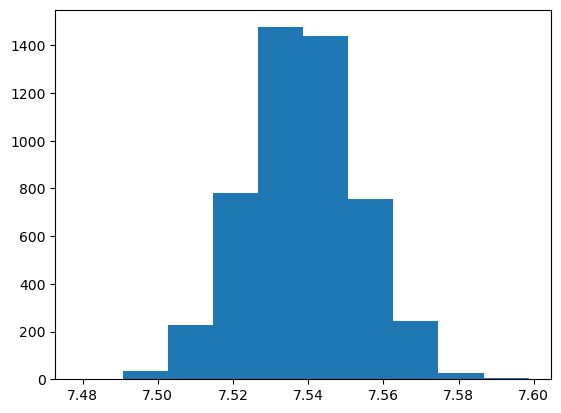

In [11]:
#yukardaki örneklemi kullanarak
#bootstrapp dağılım
import numpy as np
import matplotlib.pyplot as plt
mean_flavors_5000 = []

for i in range(5000):
    mean_flavors_5000.append(np.mean(coffee_sample.sample(frac=1, replace=True)['flavor']))

#histogramı
plt.hist(mean_flavors_5000)

In [12]:
#örneklem ortalama
coffee_sample["flavor"].mean()

7.5385

In [13]:
#bootstrap ortalama
np.mean(mean_flavors_5000)

7.538599828

In [14]:
#population ortalama
df_coffee["flavor"].mean()

7.526046337817639

In [15]:
#sample std
coffee_sample["flavor"].std()

0.3357024609450596

In [16]:
#bootstrapp std = standart error
np.std(mean_flavors_5000,ddof=1)


0.014846964208202834

In [17]:
np.std(mean_flavors_5000,ddof=1)*np.sqrt(500)

0.3319882122904788

(array([   3.,   36.,  228.,  783., 1476., 1441.,  756.,  245.,   28.,
           4.]),
 array([7.47874 , 7.490728, 7.502716, 7.514704, 7.526692, 7.53868 ,
        7.550668, 7.562656, 7.574644, 7.586632, 7.59862 ]),
 <BarContainer object of 10 artists>)

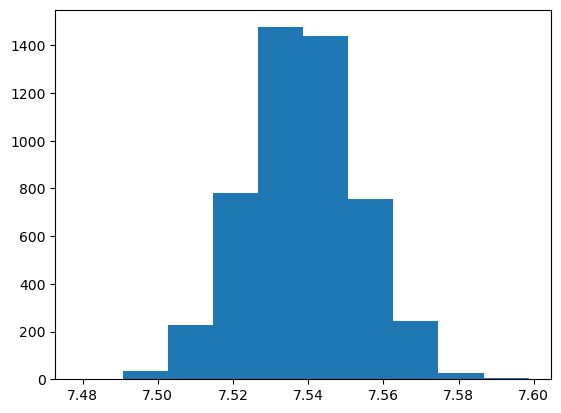

In [18]:
#bootstrap dist of mean flavor
import matplotlib.pyplot as plt

plt.hist(mean_flavors_5000)

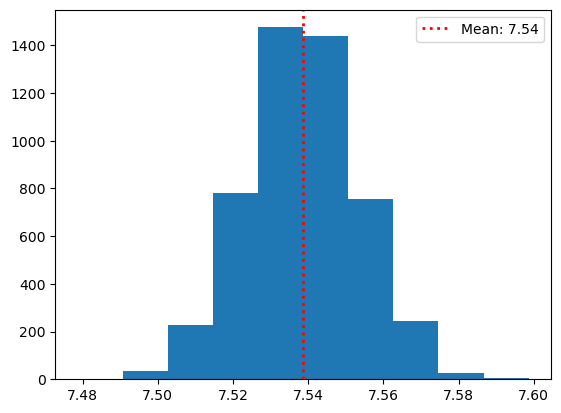

In [19]:
# Bootstrap distribution of mean flavor and mean line
plt.hist(mean_flavors_5000);
plt.axvline(np.mean(mean_flavors_5000), color='red', linestyle='dotted', linewidth=2, label=f'Mean: {np.mean(mean_flavors_5000):.2f}')
plt.legend()#label'i göstedi

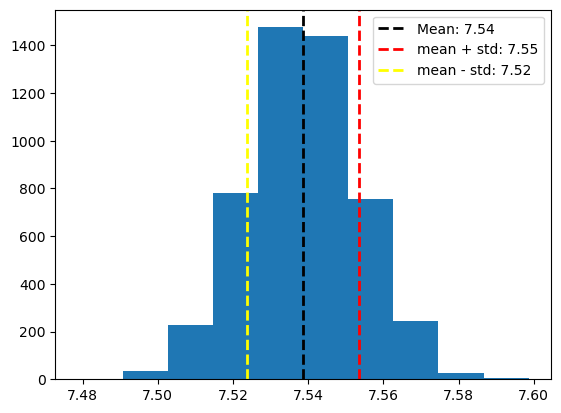

In [20]:
mean = np.mean(mean_flavors_5000)
plus_one_std = mean + np.std(mean_flavors_5000, ddof=1)
minus_one_std = mean - np.std(mean_flavors_5000, ddof=1)

plt.hist(mean_flavors_5000);

plt.axvline(mean, color='black', linestyle='dashed', linewidth=2, label=f'Mean: {mean:.2f}')

plt.axvline(plus_one_std, color='red', linestyle='dashed', linewidth=2, label=f'mean + std: {plus_one_std:.2f}')

plt.axvline(minus_one_std, color='yellow', linestyle='dashed', linewidth=2, label=f'mean - std: {minus_one_std:.2f}')

plt.legend()
#güven aralığını göstetir şekilde histogram çizilir
#confidence interval

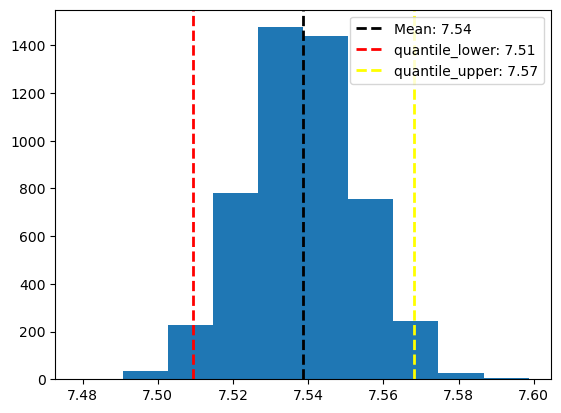

In [21]:
quantile_lower = np.quantile(mean_flavors_5000, 0.025)
quantile_upper = np.quantile(mean_flavors_5000, 0.975)

plt.hist(mean_flavors_5000);

plt.axvline(mean, color='black', linestyle='dashed', linewidth=2, label=f'Mean: {mean:.2f}')

plt.axvline(quantile_lower, color='red', linestyle='dashed', linewidth=2, label=f'quantile_lower: {quantile_lower:.2f}')

plt.axvline(quantile_upper, color='yellow', linestyle='dashed', linewidth=2, label=f'quantile_upper: {quantile_upper:.2f}')

plt.legend()
#quantile ile outliers olanları göstermiş oluruz aslında
#yorum= verilierin yüzde doksan beşi 7.49 ile 7.55 arasında


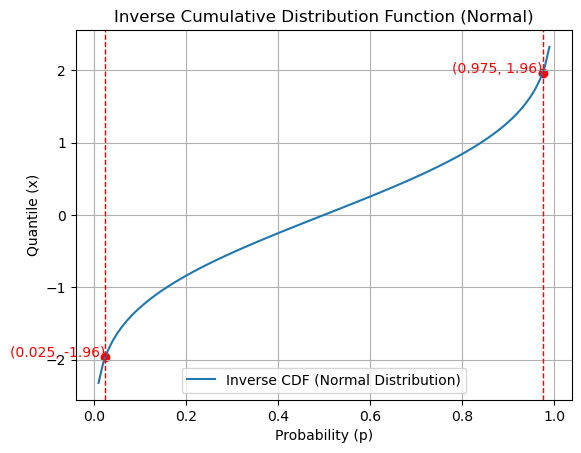

In [22]:
from scipy.stats import norm

p_values = np.linspace(0, 1, 100)

quantiles = norm.ppf(p_values, loc=0, scale=1)

plt.plot(p_values, quantiles, label="Inverse CDF (Normal Distribution)")

p1, p2 = 0.025, 0.975
quantile_025 = norm.ppf(p1)
quantile_975 = norm.ppf(p2)

plt.scatter([p1, p2], [quantile_025, quantile_975], color='red')  # Noktaları çiz
plt.axvline(p1, color='red', linestyle='dashed', linewidth=1)  # p1 için dikey çizgi
plt.axvline(p2, color='red', linestyle='dashed', linewidth=1)  # p2 için dikey çizgi

# X ve Y değerlerini grafikte gösterelim
plt.text(p1, quantile_025, f'({p1:.3f}, {quantile_025:.2f})', color='red', fontsize=10, ha='right')
plt.text(p2, quantile_975, f'({p2:.3f}, {quantile_975:.2f})', color='red', fontsize=10, ha='right')



plt.xlabel("Probability (p)")
plt.ylabel("Quantile (x)")
plt.title("Inverse Cumulative Distribution Function (Normal)")
plt.grid(True)
plt.legend()
plt.show()

In [23]:
point_estimate = np.mean(mean_flavors_5000)
point_estimate

7.538599828

In [24]:
std_error= np.std(mean_flavors_5000,ddof=1)
std_error

0.014846964208202834

In [25]:
from scipy.stats import norm

lower = norm.ppf(0.025, loc=point_estimate, scale=std_error)
upper = norm.ppf(0.975, loc=point_estimate, scale=std_error)

print(lower,upper)

7.509500312872167 7.567699343127832


In [26]:
#stackoverflow anketi
import pandas as pd

df_stck = pd.read_feather("resources/stack_overflow.feather")
df_stck

,respondent,main_branch,hobbyist,age,age_1st_code,age_first_code_cut,comp_freq,comp_total,converted_comp,country,...,survey_length,trans,undergrad_major,webframe_desire_next_year,webframe_worked_with,welcome_change,work_week_hrs,years_code,years_code_pro,age_cat
0,36.0,"I am not primarily a developer, but I write co...",Yes,34.0,30.0,adult,Yearly,60000.0,77556.0,United Kingdom,...,Appropriate in length,No,"Computer science, computer engineering, or sof...",Express;React.js,Express;React.js,Just as welcome now as I felt last year,40.0,4.0,3.0,At least 30
1,47.0,I am a developer by profession,Yes,53.0,10.0,child,Yearly,58000.0,74970.0,United Kingdom,...,Appropriate in length,No,"A natural science (such as biology, chemistry,...",Flask;Spring,Flask;Spring,Just as welcome now as I felt last year,40.0,43.0,28.0,At least 30
2,69.0,I am a developer by profession,Yes,25.0,12.0,child,Yearly,550000.0,594539.0,France,...,Too short,No,"Computer science, computer engineering, or sof...",Django;Flask,Django;Flask,Just as welcome now as I felt last year,40.0,13.0,3.0,Under 30
3,125.0,"I am not primarily a developer, but I write co...",Yes,41.0,30.0,adult,Monthly,200000.0,2000000.0,United States,...,Appropriate in length,No,None,None,None,Just as welcome now as I felt last year,40.0,11.0,11.0,At least 30
4,147.0,"I am not primarily a developer, but I write co...",No,28.0,15.0,adult,Yearly,50000.0,37816.0,Canada,...,Appropriate in length,No,"Another engineering discipline (such as civil,...",None,Express;Flask,Just as welcome now as I felt last year,40.0,5.0,3.0,Under 30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2256,62812.0,I am a developer by profession,Yes,40.0,10.0,child,Yearly,145000.0,145000.0,United States,...,Too long,No,"Computer science, computer engineering, or sof...",Flask;jQuery,Angular;Angular.js;Flask;jQuery;React.js,Somewhat less welcome now than last year,50.0,30.0,20.0,At least 30
2257,62835.0,I am a developer by profession,Yes,23.0,9.0,child,Monthly,180000.0,33972.0,Russian Federation,...,Too short,No,"Computer science, computer engineering, or sof...",ASP.NET Core,ASP.NET Core;Flask,Just as welcome now as I felt last year,60.0,8.0,3.0,Under 30
2258,62837.0,I am a developer by profession,Yes,27.0,8.0,child,Monthly,7500.0,97284.0,Germany,...,Appropriate in length,No,Mathematics or statistics,None,None,Just as welcome now as I felt last year,42.0,12.0,2.0,Under 30
2259,62867.0,"I am not primarily a developer, but I write co...",Yes,33.0,13.0,child,Monthly,6000.0,72000.0,Panama,...,Too long,No,"Another engineering discipline (such as civil,...",None,Django;React.js,A lot less welcome now than last year,45.0,15.0,2.0,At least 30


In [27]:
#elimizde olan verilere göre ortalama maaşı bulalım
mean_comp_samp= df_stck["converted_comp"].mean()
mean_comp_samp

119574.71738168952

In [28]:
import numpy as np

so_boot_distn = []

for i in range(5000):
    so_boot_distn.append(
        np.mean(df_stck.sample(frac=1, replace=True)['converted_comp']))

(array([  1.,   0.,   1.,   0.,   0.,   1.,   1.,   3.,   3.,  11.,  11.,
          9.,  23.,  43.,  50.,  77.,  87., 121., 134., 178., 205., 228.,
        275., 289., 301., 286., 293., 280., 277., 275., 261., 244., 204.,
        150., 147., 112.,  97.,  80.,  57.,  51.,  39.,  24.,  21.,  20.,
         10.,  10.,   4.,   2.,   2.,   2.]),
 array([ 97281.35161433,  98117.79010172,  98954.22858912,  99790.66707651,
        100627.10556391, 101463.5440513 , 102299.9825387 , 103136.42102609,
        103972.85951349, 104809.29800088, 105645.73648828, 106482.17497567,
        107318.61346307, 108155.05195046, 108991.49043786, 109827.92892525,
        110664.36741265, 111500.80590004, 112337.24438744, 113173.68287483,
        114010.12136223, 114846.55984962, 115682.99833702, 116519.43682441,
        117355.87531181, 118192.3137992 , 119028.7522866 , 119865.19077399,
        120701.62926139, 121538.06774878, 122374.50623618, 123210.94472357,
        124047.38321097, 124883.82169836, 125720.2

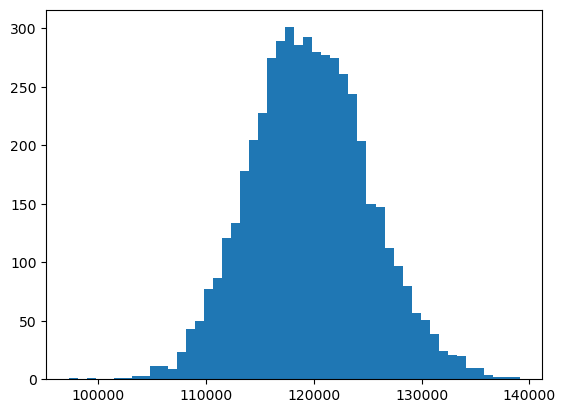

In [29]:
import matplotlib.pyplot as plt
plt.hist(so_boot_distn,bins=50)

In [30]:
std_error = np.std(so_boot_distn,ddof=1)
std_error

5500.528108821678

In [31]:
df_stck["converted_comp"].mean()

119574.71738168952

In [32]:
mean_comp_hyp = 110_000 #maaş ortalaması 110bin dolar

In [33]:
std_error

5500.528108821678

In [34]:
z_score=(mean_comp_samp-mean_comp_hyp) /std_error
z_score

1.7406905650266038

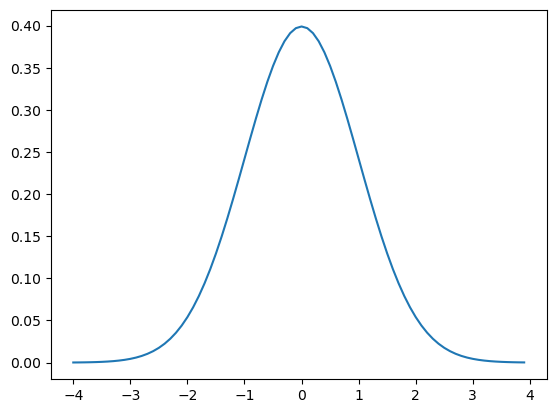

In [35]:
from scipy.stats import norm

z_data = np.arange(-4,4,0.1)

plt.plot(z_data,norm.pdf(z_data, loc=0,scale=1))

In [36]:
p_value = 1- norm.cdf(z_score,loc=0,scale=1)
p_value

0.04086891649852942

In [37]:
df_stck.groupby("age_first_code_cut")["converted_comp"].mean()

age_first_code_cut
adult    111313.311047
child    132419.570621
Name: converted_comp, dtype: float64